In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [42]:
df = pd.read_csv("../../data/raw/data_for_tree/clusters_70id_reassign.tsv", sep='\t', header=None, names=["rep", "member"])
df["protein_id"] = np.where(
    df["member"].str.contains("Centipede", case=False, na=False),
    df["member"],
    df["member"].str.split("_").str[0]
)
df

,rep,member,protein_id
0,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981
1,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981
2,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703
3,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872
4,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641
...,...,...,...
58182,P0DPX5_IPR045860_1_24-107,I6R1R5_IPR045860_1_24-110,I6R1R5
58183,P0DPX5_IPR045860_1_24-107,I6RA69_IPR045860_1_24-110,I6RA69
58184,Q8T8C6_IPR045860_1_13-112,Q8T8C6_IPR045860_1_13-112,Q8T8C6
58185,R7UXY0_IPR045860_1_94-150,R7UXY0_IPR045860_1_94-150,R7UXY0


In [43]:
rep_to_cluster = {rep: i for i, rep in enumerate(sorted(df["rep"].unique()))}
df["cluster_id"] = df["rep"].map(rep_to_cluster)
df

,rep,member,protein_id,cluster_id
0,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,11103
1,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,11130
2,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,11180
3,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872,4329
4,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641,8912
...,...,...,...,...
58182,P0DPX5_IPR045860_1_24-107,I6R1R5_IPR045860_1_24-110,I6R1R5,11708
58183,P0DPX5_IPR045860_1_24-107,I6RA69_IPR045860_1_24-110,I6RA69,11708
58184,Q8T8C6_IPR045860_1_13-112,Q8T8C6_IPR045860_1_13-112,Q8T8C6,11854
58185,R7UXY0_IPR045860_1_94-150,R7UXY0_IPR045860_1_94-150,R7UXY0,11951


In [44]:
# Count how many members each cluster has
df["cluster_id"].value_counts()

cluster_id
5469     1337
2351      830
1690      681
11454     665
8573      653
         ... 
1508        1
11728       1
11523       1
11244       1
12028       1
Name: count, Length: 12188, dtype: int64

In [45]:
metadata = pd.read_csv("../../data/interm/merged/merged.csv")
metadata

,protein_id,protein_name,organism,sequence_length,tax_id,interpro_1,interpro_2,interpro_3,interpro_4
0,A0A016RUD2,Activin types I and II receptor domain-contain...,Ancylostoma ceylanicum,102,53326.0,IPR045860,NaN,NaN,NaN
1,A0A016SEB0,UPAR/Ly6 domain-containing protein qvr,Ancylostoma ceylanicum,160,53326.0,IPR031424,NaN,NaN,NaN
2,A0A016SHP2,Protein quiver,Ancylostoma ceylanicum,171,53326.0,IPR031424,NaN,NaN,NaN
3,A0A016SK76,UPAR/Ly6 domain-containing protein,Ancylostoma ceylanicum,685,53326.0,IPR045860,NaN,NaN,NaN
4,A0A016SKC5,Mos1 transposase HTH domain-containing protein,Ancylostoma ceylanicum,755,53326.0,IPR045860,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
52824,X1WGJ5,UPAR/Ly6 domain-containing protein,Danio rerio (Zebrafish),126,7955.0,IPR016054,IPR045860,NaN,NaN
52825,X1YV74,Serine/threonine-protein kinase receptor,Capitella teleta,488,283909.0,IPR045860,NaN,NaN,NaN
52826,X2ACF0,Protein sleepless,Capitella teleta (Polychaete worm),106,NaN,IPR031424,NaN,NaN,NaN
52827,X2ATT7,Snake toxin/toxin-like domain-containing protein,Capitella teleta,157,283909.0,IPR045860,NaN,NaN,NaN


In [46]:
# Initialize an empty list to store results
merged_list = []

for _, row in df.iterrows():
    member = row['member']
    # Find all metadata rows where identifier is substring of member
    matches = metadata[metadata['protein_id'].apply(lambda x: x in member)].copy()
    if matches.empty:
        # If no match, keep the df row with NaNs for metadata columns
        merged_list.append({**row})
    else:
        for _, m_row in matches.iterrows():
            merged_list.append({**row, **m_row.to_dict()})

df_merged = pd.DataFrame(merged_list)

# Reorder columns: member, cluster_id first
cols = ['member','cluster_id'] + [c for c in df_merged.columns if c not in ['member','cluster_id']]
df_merged = df_merged[cols]

In [47]:
df_merged["cluster_id"].value_counts()

cluster_id
5469     1337
2351      830
1690      681
11454     665
8573      653
         ... 
1508        1
11728       1
11523       1
11244       1
12028       1
Name: count, Length: 12188, dtype: int64

In [48]:
df_merged

,member,cluster_id,rep,protein_id,protein_name,organism,sequence_length,tax_id,interpro_1,interpro_2,interpro_3,interpro_4
0,Centipede3FTx_0001_61981,11103,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Centipede3FTx_0033_61981,11130,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Centipede3FTx_0097_984703,11180,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A0A7J7F872_IPR042339_1_14-139,4329,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872,UPAR/Ly6 domain-containing protein,Diceros bicornis minor (South-central black rh...,139.0,77932.0,IPR016054,IPR035076,IPR042339,IPR045860
4,A0AAD4U641_IPR016054_2_166-237,8912,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641,UPAR/Ly6 domain-containing protein,Ovis ammon polii,401.0,230172.0,IPR016054,IPR035076,IPR042339,IPR045860
...,...,...,...,...,...,...,...,...,...,...,...,...
58184,I6R1R5_IPR045860_1_24-110,11708,P0DPX5_IPR045860_1_24-107,I6R1R5,Omega-scoloptoxin(05)-Ssm1a,Scolopendra mutilans,129.0,2836329.0,IPR045860,NaN,NaN,NaN
58185,I6RA69_IPR045860_1_24-110,11708,P0DPX5_IPR045860_1_24-107,I6RA69,Putative Ca2+ channel activator,Scolopendra subspinipes,136.0,55038.0,IPR045860,NaN,NaN,NaN
58186,Q8T8C6_IPR045860_1_13-112,11854,Q8T8C6_IPR045860_1_13-112,Q8T8C6,Serine/threonine-protein kinase receptor,Halocynthia roretzi,591.0,7729.0,IPR045860,NaN,NaN,NaN
58187,R7UXY0_IPR045860_1_94-150,11951,R7UXY0_IPR045860_1_94-150,R7UXY0,UPAR/Ly6 domain-containing protein,Capitella teleta,177.0,283909.0,IPR045860,NaN,NaN,NaN


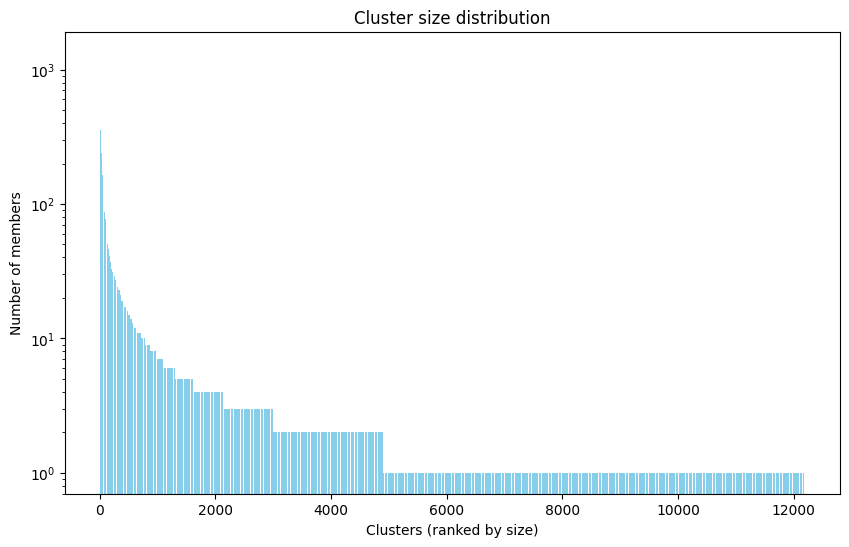

In [49]:
# count members per cluster and sort descending
cluster_sizes = df_merged.groupby("cluster_id")["member"].count().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(range(len(cluster_sizes)), cluster_sizes.values, color='skyblue')
plt.xlabel("Clusters (ranked by size)")
plt.ylabel("Number of members")
plt.yscale('log')
plt.title("Cluster size distribution")
plt.show()

In [ ]:
# (((xref:interpro-IPR016054 OR xref:interpro-IPR026110 OR xref:interpro-IPR026524 OR xref:interpro-IPR031424 OR xref:interpro-IPR038773 OR xref:interpro-IPR039457 OR xref:interpro-IPR039237 OR xref:interpro-IPR042339 OR xref:interpro-IPR051445 OR xref:interpro-IPR035076 OR xref:interpro-IPR003571 OR xref:interpro-IPR045860) AND fragment:false) OR (accession:I6R1R5 OR accession:P0DPX5 OR accession:P0DPX9 OR accession:P0DPY0 OR accession:P0DPY1 OR accession:P0DPX7 OR accession:P0DPX8 OR accession:P0DPX6 OR accession:P0DPU8)) AND (taxonomy_id:33208)